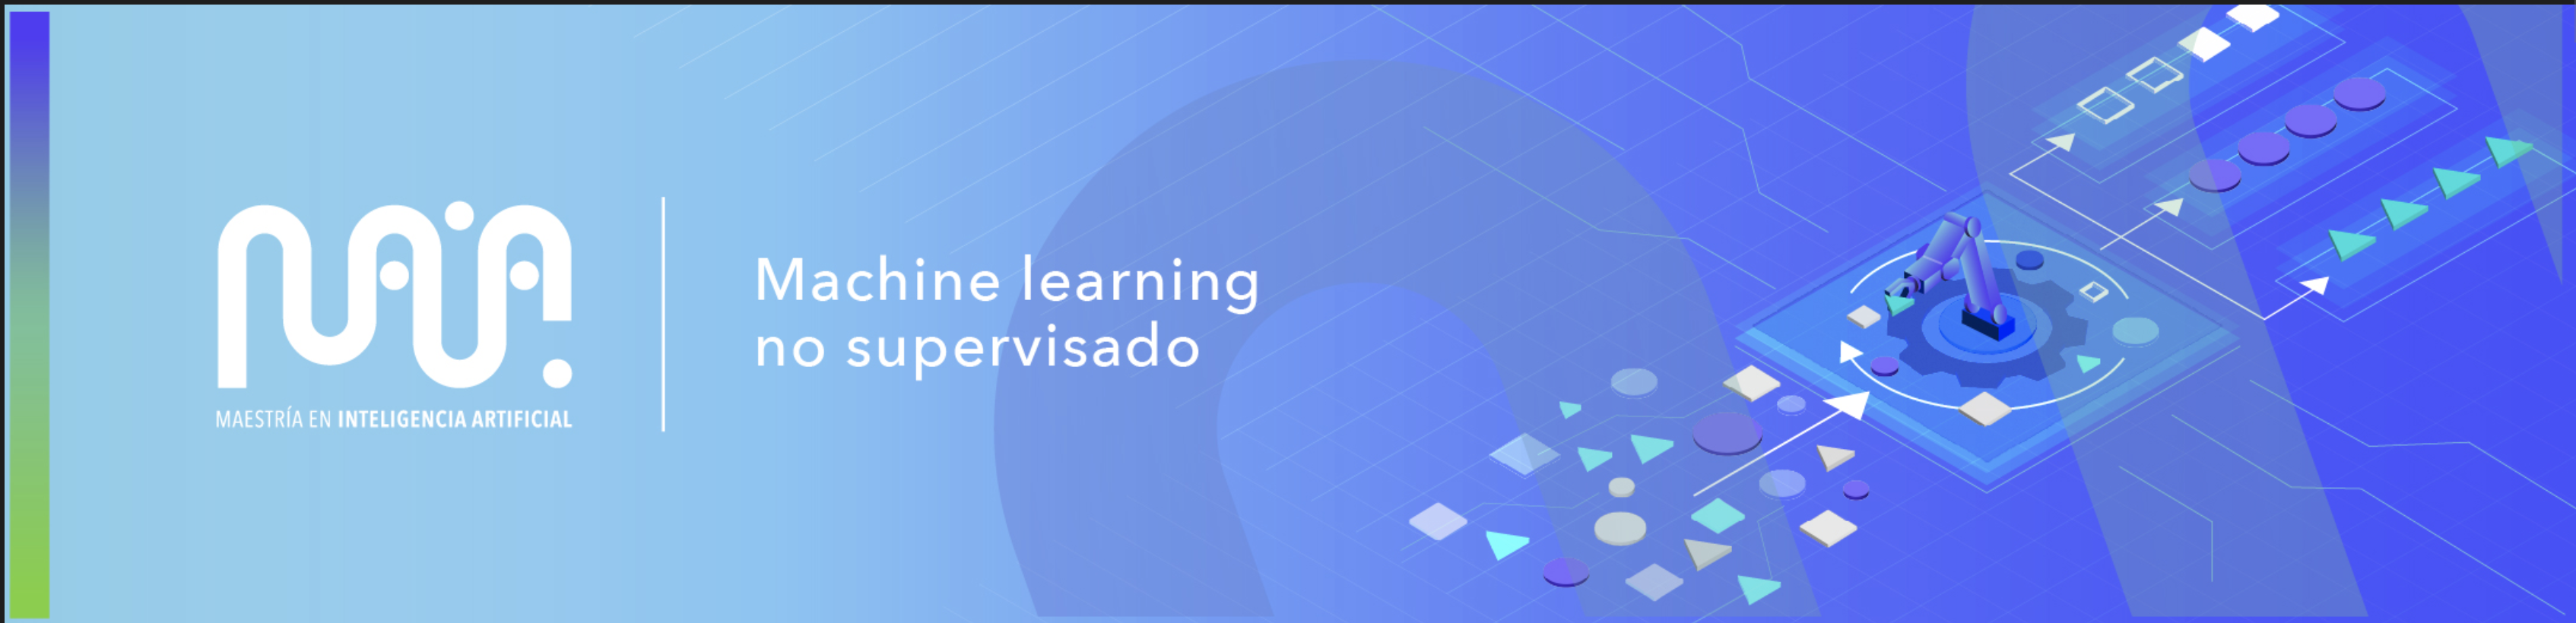

## Alcanzando los objetivos de desarrollo sostenible. Un aporte desde el machine learning.


## Objetivo.
* Desarrollar una solución, basada en técnicas de procesamiento de lenguaje natural y machine learning, que facilite la interpretación y análisis de información textual para la identificación de relaciones semánticas con los Objetivos de Desarrollo Sostenibles.


## Integrantes grupo No. 58

- Carlos A Diaz (**c.diazm2@uniandes.edu.co**)
- Nataly Tinoco (**jn.tinoco@uniandes.edu.co**)

## Contenido
1. [Importación de librerías requeridas](#1.-Importación-de-librerías-requeridas)
2. [Funciones](#2.-Funciones)
3. [Carga y exploración de datos](#3.-Carga-y-exploración-de-datos)
4. [Pruebas para elegir el modelo](#4.-Pruebas-para-elegir-el-modelo)
5. [Métricas y evaluación](#5.-Métricas-y-evaluación)
6. [Modelo final y cómo funciona](#6.-Modelo-final-y-cómo-funciona)



In [1]:
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 33.5 MB/s  0:00:00eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')


## 1. Importación de librerías requeridas


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
from nltk import RegexpTokenizer
from nltk.corpus import stopwords
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/natalytinoco/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/natalytinoco/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)


In [4]:
import unicodedata
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from nltk.stem import SnowballStemmer
stemmer = SnowballStemmer("spanish")

nltk.download('stopwords')
stop_words = set(stopwords.words('spanish'))

import spacy
nlp = spacy.load("es_core_news_sm")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/natalytinoco/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
from pycaret.classification import setup, compare_models

In [6]:
#from google.colab import drive
#drive.mount('/content/drive')

## 2. Funciones


In [7]:
def limpiar_texto_stem(texto):
    # 1. Normalizar y quitar acentos
    texto = unicodedata.normalize('NFKD', texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))

    # 2. Minúsculas
    texto = texto.lower()

    # 3. Eliminar números
    texto = re.sub(r'\d+', ' ', texto)

    # 4. Eliminar puntuación (dejamos solo letras y espacios)
    texto = re.sub(r'[^a-zA-ZñÑáéíóúü\s]', ' ', texto)

    # 5. Tokenizar
    tokens = word_tokenize(texto)

    # 6. Eliminar stopwords y tokens muy cortos
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    # stemming
    tokens = [stemmer.stem(w) for w in tokens]

    return " ".join(tokens)

In [8]:
## si lo hacemos con spicy? se demora un poco mas
def limpiar_texto(texto):
    # 1. Normalizar y quitar acentos
    texto = unicodedata.normalize('NFKD', texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))

    # 2. Minúsculas
    texto = texto.lower()

    # 3. Eliminar números
    texto = re.sub(r'\d+', ' ', texto)

    # 4. Eliminar puntuación (dejamos solo letras y espacios)
    texto = re.sub(r'[^a-zA-ZñÑáéíóúü\s]', ' ', texto)

    doc = nlp(texto)

    tokens = [
        token.lemma_
        for token in doc
        if token.lemma_ not in stop_words
        and token.is_alpha
        and len(token.lemma_) > 2
    ]

    return " ".join(tokens)

## 3. Carga y exploración de datos


In [9]:
#df = pd.read_excel('/content/drive/MyDrive/MAESTRIA/Microproyecto_1/Train_textosODS.xlsx')
df = pd.read_excel('/Users/natalytinoco/Downloads/ML NO supervisado/microproyecto 2/Train_textosODS.xlsx')

In [10]:
df.shape

(9656, 2)

In [11]:
df.head()

,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13
3,Con el Congreso firmemente en control de la ju...,16
4,"Luego, dos secciones finales analizan las impl...",5


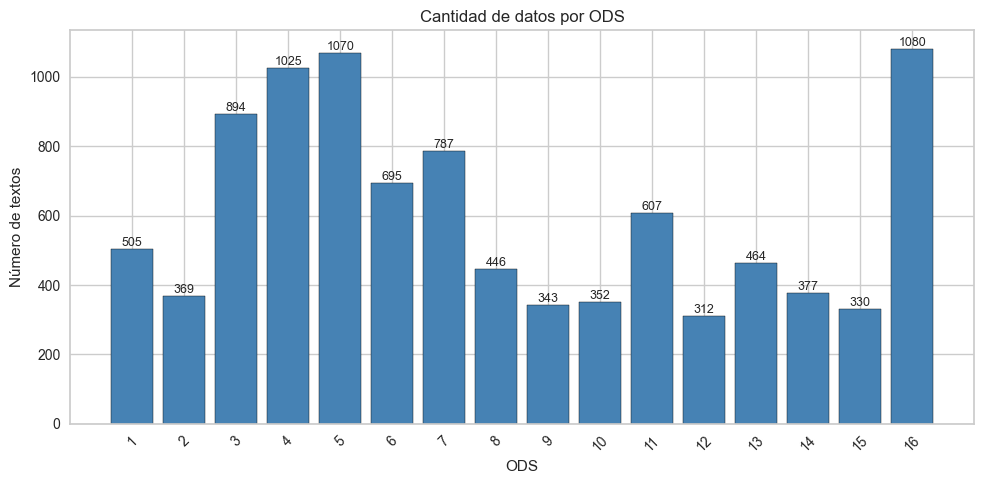

In [12]:
## podemos poner que hay un claro desbalance.
conteos_ods = df["ODS"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
bars = plt.bar(conteos_ods.index.astype(str), conteos_ods.values,
               color="steelblue", edgecolor="black")

plt.xlabel("ODS")
plt.ylabel("Número de textos")
plt.title("Cantidad de datos por ODS")
plt.xticks(rotation=45)
for x, y in zip(conteos_ods.index.astype(str), conteos_ods.values):
    plt.text(x, y, str(y),
             ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

mirar ejemplos por ODS para saber  si quitar stop words ayudaria o no, en este caso sirve pero tal vez podriamo conservar palabras que ayuden a identificar desigualdades o no quitarlas y esperar que el tif las pese como menos importante..?...

In [13]:
## aqui podemos justificar que queriamos hacer una pequeña exploracion con una muestra.. solo para saber con que datos estamos trabajndo
ejemplos = (
    df.groupby("ODS")
      .sample(1, random_state=42)
      .sort_values("ODS")
)
ejemplos

,textos,ODS
3147,"En tres (Chile, Perú y Uruguay), el efecto de ...",1
1800,Las barras y los rombos indican los rangos y l...,2
3912,Esto contrasta con otros modelos que no incluy...,3
8870,"Para garantizar la calidad de la EAPI, el pers...",4
2332,"En respuesta a estos desafíos, los países han ...",5
4342,Esta solución puede ser adecuada para una masa...,6
5898,El informe demuestra el caso comercial del uso...,7
8285,"Al fin y al cabo, las infraestructuras necesar...",8
6459,"El cuarto plan móvil de 5 años, Smart Rwanda M...",9
7142,Es necesario que los formuladores de políticas...,10


ir viendo paso a paso como se verian los ejemplos con cada parte del pipeline, ya despues se aplica a todo

In [14]:
ejemplos["new_text"] = ejemplos["textos"].apply(
    lambda texto: "".join(
        c for c in unicodedata.normalize('NFKD', texto)
        if not unicodedata.combining(c)
    )
)
ejemplos.head(3)

,textos,ODS,new_text
3147,"En tres (Chile, Perú y Uruguay), el efecto de ...",1,"En tres (Chile, Peru y Uruguay), el efecto de ..."
1800,Las barras y los rombos indican los rangos y l...,2,Las barras y los rombos indican los rangos y l...
3912,Esto contrasta con otros modelos que no incluy...,3,Esto contrasta con otros modelos que no incluy...


In [15]:
ejemplos["new_text"] = ejemplos["new_text"].str.lower()
ejemplos.head(3)

,textos,ODS,new_text
3147,"En tres (Chile, Perú y Uruguay), el efecto de ...",1,"en tres (chile, peru y uruguay), el efecto de ..."
1800,Las barras y los rombos indican los rangos y l...,2,las barras y los rombos indican los rangos y l...
3912,Esto contrasta con otros modelos que no incluy...,3,esto contrasta con otros modelos que no incluy...


In [16]:
ejemplos["new_text"] = ejemplos["new_text"].apply(
    lambda texto: re.sub(r'\d+', ' ', texto)
)
ejemplos.head(3)

,textos,ODS,new_text
3147,"En tres (Chile, Perú y Uruguay), el efecto de ...",1,"en tres (chile, peru y uruguay), el efecto de ..."
1800,Las barras y los rombos indican los rangos y l...,2,las barras y los rombos indican los rangos y l...
3912,Esto contrasta con otros modelos que no incluy...,3,esto contrasta con otros modelos que no incluy...


In [17]:
ejemplos["new_text"] = ejemplos["new_text"].apply(
    lambda texto: re.sub(r'[^a-zñ\s]', ' ', texto)
)

ejemplos.head(3)

,textos,ODS,new_text
3147,"En tres (Chile, Perú y Uruguay), el efecto de ...",1,en tres chile peru y uruguay el efecto de ...
1800,Las barras y los rombos indican los rangos y l...,2,las barras y los rombos indican los rangos y l...
3912,Esto contrasta con otros modelos que no incluy...,3,esto contrasta con otros modelos que no incluy...


In [18]:
pd.set_option('display.max_colwidth', None)
ejemplos["new_text"] = ejemplos["new_text"].apply(lambda x: word_tokenize(x))
ejemplos.head(3)

,textos,ODS,new_text
3147,"En tres (Chile, Perú y Uruguay), el efecto de este factor se vio potenciado por una mejora en la distribución, al menos en el área de distribución cercana a la línea de pobreza. Por otro lado, la tendencia a la baja de la pobreza en Argentina y República Dominicana fue, en parte, frenada —no ayudada— por cambios en la distribución. En otro grupo de cinco países, el efecto distribución fue el principal determinante de la caída de las tasas de pobreza.",1,"[en, tres, chile, peru, y, uruguay, el, efecto, de, este, factor, se, vio, potenciado, por, una, mejora, en, la, distribucion, al, menos, en, el, area, de, distribucion, cercana, a, la, linea, de, pobreza, por, otro, lado, la, tendencia, a, la, baja, de, la, pobreza, en, argentina, y, republica, dominicana, fue, en, parte, frenada, no, ayudada, por, cambios, en, la, distribucion, en, otro, grupo, de, cinco, paises, el, efecto, distribucion, fue, el, principal, determinante, de, la, caida, de, las, tasas, de, pobreza]"
1800,"Las barras y los rombos indican los rangos y las medias de los modelos, respectivamente. Las tres regiones del mundo incluyen América, Europa, África y Oriente Medio, y Asia y Oceanía. Los cambios mostrados son relativos al escenario respectivo sin cambio de políticas. Un sistema de comercio que funcione correctamente desempeña un papel importante a la hora de amortiguar las perturbaciones locales y regionales de la oferta, como las relacionadas con condiciones meteorológicas extremas o disturbios civiles, y de mitigar sus efectos adversos sobre la seguridad alimentaria (Baldos y Hertel, 2015).",2,"[las, barras, y, los, rombos, indican, los, rangos, y, las, medias, de, los, modelos, respectivamente, las, tres, regiones, del, mundo, incluyen, america, europa, africa, y, oriente, medio, y, asia, y, oceania, los, cambios, mostrados, son, relativos, al, escenario, respectivo, sin, cambio, de, politicas, un, sistema, de, comercio, que, funcione, correctamente, desempena, un, papel, importante, a, la, hora, de, amortiguar, las, perturbaciones, locales, y, regionales, de, la, oferta, como, las, relacionadas, con, condiciones, meteorologicas, extremas, o, disturbios, civiles, y, de, mitigar, sus, efectos, adversos, sobre, la, seguridad, alimentaria, baldos, y, hertel]"
3912,"Esto contrasta con otros modelos que no incluyen explícitamente el cambio tecnológico. No se incluyen los costos de administración e infraestructura que pueden ser necesarios para satisfacer la demanda de atención de salud proyectada. De manera similar, el modelo no considera el impacto del ingreso nacional o los presupuestos de salud en la demanda de servicios de salud.",3,"[esto, contrasta, con, otros, modelos, que, no, incluyen, explicitamente, el, cambio, tecnologico, no, se, incluyen, los, costos, de, administracion, e, infraestructura, que, pueden, ser, necesarios, para, satisfacer, la, demanda, de, atencion, de, salud, proyectada, de, manera, similar, el, modelo, no, considera, el, impacto, del, ingreso, nacional, o, los, presupuestos, de, salud, en, la, demanda, de, servicios, de, salud]"


In [19]:
# Solo estas 3 están realmente en las stop words de NLTK español
palabras_importantes = {"no", "sin", "contra"}

## de esto nos dimos cuenta  despues de mirar las nubes de palabras,
## estas ocupaban gran espacio en todos los ODS.
ruido_extra = {
    "ser", "haber", "deber", "poder",
    "ejemplo", "tambien", "tener",
    "hacer", "dar", "ano"
}

stop_words = stop_words.union(ruido_extra)
stop_words = stop_words - palabras_importantes

ejemplos["new_text"] = ejemplos["new_text"].apply(
    lambda tokens: [w for w in tokens if w not in stop_words and len(w) > 2]
)
ejemplos.head(3)


,textos,ODS,new_text
3147,"En tres (Chile, Perú y Uruguay), el efecto de este factor se vio potenciado por una mejora en la distribución, al menos en el área de distribución cercana a la línea de pobreza. Por otro lado, la tendencia a la baja de la pobreza en Argentina y República Dominicana fue, en parte, frenada —no ayudada— por cambios en la distribución. En otro grupo de cinco países, el efecto distribución fue el principal determinante de la caída de las tasas de pobreza.",1,"[tres, chile, peru, uruguay, efecto, factor, vio, potenciado, mejora, distribucion, menos, area, distribucion, cercana, linea, pobreza, lado, tendencia, baja, pobreza, argentina, republica, dominicana, parte, frenada, ayudada, cambios, distribucion, grupo, cinco, paises, efecto, distribucion, principal, determinante, caida, tasas, pobreza]"
1800,"Las barras y los rombos indican los rangos y las medias de los modelos, respectivamente. Las tres regiones del mundo incluyen América, Europa, África y Oriente Medio, y Asia y Oceanía. Los cambios mostrados son relativos al escenario respectivo sin cambio de políticas. Un sistema de comercio que funcione correctamente desempeña un papel importante a la hora de amortiguar las perturbaciones locales y regionales de la oferta, como las relacionadas con condiciones meteorológicas extremas o disturbios civiles, y de mitigar sus efectos adversos sobre la seguridad alimentaria (Baldos y Hertel, 2015).",2,"[barras, rombos, indican, rangos, medias, modelos, respectivamente, tres, regiones, mundo, incluyen, america, europa, africa, oriente, medio, asia, oceania, cambios, mostrados, relativos, escenario, respectivo, sin, cambio, politicas, sistema, comercio, funcione, correctamente, desempena, papel, importante, hora, amortiguar, perturbaciones, locales, regionales, oferta, relacionadas, condiciones, meteorologicas, extremas, disturbios, civiles, mitigar, efectos, adversos, seguridad, alimentaria, baldos, hertel]"
3912,"Esto contrasta con otros modelos que no incluyen explícitamente el cambio tecnológico. No se incluyen los costos de administración e infraestructura que pueden ser necesarios para satisfacer la demanda de atención de salud proyectada. De manera similar, el modelo no considera el impacto del ingreso nacional o los presupuestos de salud en la demanda de servicios de salud.",3,"[contrasta, modelos, incluyen, explicitamente, cambio, tecnologico, incluyen, costos, administracion, infraestructura, pueden, necesarios, satisfacer, demanda, atencion, salud, proyectada, manera, similar, modelo, considera, impacto, ingreso, nacional, presupuestos, salud, demanda, servicios, salud]"


In [20]:
ejemplos["new_text_stem"] = ejemplos["new_text"].apply(
    lambda tokens: " ".join(stemmer.stem(w) for w in tokens)
)

ejemplos[["ODS", "textos", "new_text", "new_text_stem"]].head(3)

,ODS,textos,new_text,new_text_stem
3147,1,"En tres (Chile, Perú y Uruguay), el efecto de este factor se vio potenciado por una mejora en la distribución, al menos en el área de distribución cercana a la línea de pobreza. Por otro lado, la tendencia a la baja de la pobreza en Argentina y República Dominicana fue, en parte, frenada —no ayudada— por cambios en la distribución. En otro grupo de cinco países, el efecto distribución fue el principal determinante de la caída de las tasas de pobreza.","[tres, chile, peru, uruguay, efecto, factor, vio, potenciado, mejora, distribucion, menos, area, distribucion, cercana, linea, pobreza, lado, tendencia, baja, pobreza, argentina, republica, dominicana, parte, frenada, ayudada, cambios, distribucion, grupo, cinco, paises, efecto, distribucion, principal, determinante, caida, tasas, pobreza]",tres chil peru uruguay efect factor vio potenci mejor distribucion men are distribucion cercan line pobrez lad tendenci baj pobrez argentin republ dominican part fren ayud cambi distribucion grup cinc pais efect distribucion principal determin caid tas pobrez
1800,2,"Las barras y los rombos indican los rangos y las medias de los modelos, respectivamente. Las tres regiones del mundo incluyen América, Europa, África y Oriente Medio, y Asia y Oceanía. Los cambios mostrados son relativos al escenario respectivo sin cambio de políticas. Un sistema de comercio que funcione correctamente desempeña un papel importante a la hora de amortiguar las perturbaciones locales y regionales de la oferta, como las relacionadas con condiciones meteorológicas extremas o disturbios civiles, y de mitigar sus efectos adversos sobre la seguridad alimentaria (Baldos y Hertel, 2015).","[barras, rombos, indican, rangos, medias, modelos, respectivamente, tres, regiones, mundo, incluyen, america, europa, africa, oriente, medio, asia, oceania, cambios, mostrados, relativos, escenario, respectivo, sin, cambio, politicas, sistema, comercio, funcione, correctamente, desempena, papel, importante, hora, amortiguar, perturbaciones, locales, regionales, oferta, relacionadas, condiciones, meteorologicas, extremas, disturbios, civiles, mitigar, efectos, adversos, seguridad, alimentaria, baldos, hertel]",barr romb indic rang medi model respect tres region mund inclu amer europ afric orient medi asi oceani cambi mostr relat escenari respect sin cambi polit sistem comerci funcion correct desempen papel import hor amortigu perturb local regional ofert relacion condicion meteorolog extrem disturbi civil mitig efect advers segur alimentari bald hertel
3912,3,"Esto contrasta con otros modelos que no incluyen explícitamente el cambio tecnológico. No se incluyen los costos de administración e infraestructura que pueden ser necesarios para satisfacer la demanda de atención de salud proyectada. De manera similar, el modelo no considera el impacto del ingreso nacional o los presupuestos de salud en la demanda de servicios de salud.","[contrasta, modelos, incluyen, explicitamente, cambio, tecnologico, incluyen, costos, administracion, infraestructura, pueden, necesarios, satisfacer, demanda, atencion, salud, proyectada, manera, similar, modelo, considera, impacto, ingreso, nacional, presupuestos, salud, demanda, servicios, salud]",contrast model inclu explicit cambi tecnolog inclu cost administr infraestructur pued necesari satisfac demand atencion salud proyect maner simil model consider impact ingres nacional presupuest salud demand servici salud


In [21]:
ejemplos["new_text_lemma_spacy"] = ejemplos["new_text"].apply(
    lambda tokens: " ".join(
        token.lemma_
        for token in nlp(" ".join(tokens))
        if token.lemma_ not in stop_words
        and token.is_alpha
        and len(token.lemma_) > 2
    )
)

ejemplos[["ODS", "textos", "new_text", "new_text_lemma_spacy"]].head(3)

,ODS,textos,new_text,new_text_lemma_spacy
3147,1,"En tres (Chile, Perú y Uruguay), el efecto de este factor se vio potenciado por una mejora en la distribución, al menos en el área de distribución cercana a la línea de pobreza. Por otro lado, la tendencia a la baja de la pobreza en Argentina y República Dominicana fue, en parte, frenada —no ayudada— por cambios en la distribución. En otro grupo de cinco países, el efecto distribución fue el principal determinante de la caída de las tasas de pobreza.","[tres, chile, peru, uruguay, efecto, factor, vio, potenciado, mejora, distribucion, menos, area, distribucion, cercana, linea, pobreza, lado, tendencia, baja, pobreza, argentina, republica, dominicana, parte, frenada, ayudada, cambios, distribucion, grupo, cinco, paises, efecto, distribucion, principal, determinante, caida, tasas, pobreza]",tres chile peru uruguay efecto factor ver potenciado mejora distribucion menos area distribucion cercano line pobreza lado tendencia bajo pobreza argentino republico dominicano parte frenado ayudado cambio distribucion grupo cinco país efecto distribucion principal determinante caido tasa pobreza
1800,2,"Las barras y los rombos indican los rangos y las medias de los modelos, respectivamente. Las tres regiones del mundo incluyen América, Europa, África y Oriente Medio, y Asia y Oceanía. Los cambios mostrados son relativos al escenario respectivo sin cambio de políticas. Un sistema de comercio que funcione correctamente desempeña un papel importante a la hora de amortiguar las perturbaciones locales y regionales de la oferta, como las relacionadas con condiciones meteorológicas extremas o disturbios civiles, y de mitigar sus efectos adversos sobre la seguridad alimentaria (Baldos y Hertel, 2015).","[barras, rombos, indican, rangos, medias, modelos, respectivamente, tres, regiones, mundo, incluyen, america, europa, africa, oriente, medio, asia, oceania, cambios, mostrados, relativos, escenario, respectivo, sin, cambio, politicas, sistema, comercio, funcione, correctamente, desempena, papel, importante, hora, amortiguar, perturbaciones, locales, regionales, oferta, relacionadas, condiciones, meteorologicas, extremas, disturbios, civiles, mitigar, efectos, adversos, seguridad, alimentaria, baldos, hertel]",barra rombo indicar rango medio modelo respectivamente tres región mundo incluir americo europa africo oriente medio asia oceanio cambio mostrado relativo escenario respectivo sin cambio politica sistema comercio funcionir correctamente desempenar papel importante hora amortiguar perturbación local regional oferta relacionado condición meteorologica extremo disturbio civil mitigar efecto adverso seguridad alimentario baldo hertel
3912,3,"Esto contrasta con otros modelos que no incluyen explícitamente el cambio tecnológico. No se incluyen los costos de administración e infraestructura que pueden ser necesarios para satisfacer la demanda de atención de salud proyectada. De manera similar, el modelo no considera el impacto del ingreso nacional o los presupuestos de salud en la demanda de servicios de salud.","[contrasta, modelos, incluyen, explicitamente, cambio, tecnologico, incluyen, costos, administracion, infraestructura, pueden, necesarios, satisfacer, demanda, atencion, salud, proyectada, manera, similar, modelo, considera, impacto, ingreso, nacional, presupuestos, salud, demanda, servicios, salud]",contrastar modelo incluir explicitamente cambio tecnologico incluir costo administracion infraestructuro necesario satisfacer demanda atencion salud proyectado manera similar modelo considerar impacto ingreso nacional presupuesto salud demandar servicio salud


In [22]:
## lo hacemos con todo el conjunto de datos.
df["texto_limpio_stem"] = df["textos"].apply(limpiar_texto_stem)
df["texto_limpio_spacy"] = df["textos"].apply(limpiar_texto)
df.head(3)

,textos,ODS,texto_limpio_stem,texto_limpio_spacy
0,"""Aprendizaje"" y ""educación"" se consideran sinónimos de escolarización formal. Las organizaciones auxiliares, como las editoriales de educación, las juntas examinadoras y las organizaciones de formación de docentes, se consideran extensiones de los acuerdos establecidos por los gobiernos. Este marco de comprensión se ha vuelto cada vez más inadecuado.",4,aprendizaj educ consider sinon escolariz formal organiz auxiliar editorial educ junt examin organiz formacion docent consider extension acuerd establec gobi marc comprension vuelt cad vez mas inadecu,aprendizaje educacion considerar sinonimo escolarizacion formal organización auxiliar editorial educacion junto examinadora organización formacion docente considerar extensión acuerdo establecido gobierno marco comprension volver cada vez mas inadecuado
1,"No dejar clara la naturaleza de estos riesgos puede dar lugar a un exceso de inversión en empresas dependientes del agua y a peticiones de compensación cuando haya que reducir los derechos para evitar comprometer la calidad del agua y otros resultados medioambientales. Por ejemplo, es fundamental evitar cualquier escasez en la disponibilidad de agua para la refrigeración de centrales nucleares, ya que las consecuencias son inaceptablemente elevadas. Sin embargo, los agricultores que se dedican a cultivos anuales de escaso valor pueden estar dispuestos a renunciar al uso del agua en épocas de escasez, especialmente si pueden recuperar un mayor valor comerciando con sus derechos de agua para usos de mayor valor que el que pueden recuperar utilizando el agua. Los distintos usuarios del agua también tienen diferentes capacidades para gestionar el riesgo de escasez de agua dulce, mejorando la eficiencia, recurriendo a fuentes de agua alternativas o ajustando el calendario de su uso del agua.",6,dej clar naturalez riesg pued lug exces inversion empres dependient agu peticion compens reduc derech evit compromet calid agu result medioambiental fundamental evit cualqui escasez disponibil agu refriger central nuclear consecuent inacept elev sin embarg agricultor dedic cultiv anual escas valor pued dispuest renunci uso agu epoc escasez especial pued recuper mayor valor comerci derech agu usos mayor valor pued recuper utiliz agu distint usuari agu diferent capac gestion riesg escasez agu dulc mejor eficient recurr fuent agu altern ajust calendari uso agu,dejar claro naturaleza riesgo lugar exceso inversion empresa dependiente agua petición compensacion reducir derecho evitar comprometer calidad agua resultado medioambiental fundamental evitar cualquiera escasez disponibilidad agua refrigeracion central nuclear consecuencia inaceptablemente elevado sin embargo agricultor dedicar cultivo anual escaso valor dispuesto renunciar uso agua epocas escasez especialmente recuperar mayor valor comerciar derecho agua uso mayor valor recuperar utilizar agua distinto usuario agua diferente capacidad gestionar riesgo escasez agua dulce mejorar eficiencia recurrir fuente agua alternativo ajustar calendario uso agua
2,"Como resultado, un mayor y mejorado acceso al agua puede afectar aún más la capacidad de adaptación y resiliencia de las comunidades al cambio climático. Para la adaptación, muchos marcos de resultados contienen indicadores para rastrear los impactos en estas áreas. Por ejemplo, el ""Programa Piloto para la Resiliencia Climática"" (PPCR) de los CIF y la República de Kenia (Kenia) incluyen indicadores sobre el acceso a agua segura y confiable (CIF, 2012b y Kenia, 2013). En el área de la seguridad alimentaria, Kenia también rastrea cuántas hectáreas de tierra productiva se han perdido por la erosión del suelo y cuántos hogares necesitan ayuda alimentaria como parte de sus sistemas nacionales de M&E para evaluar la resiliencia climática y la capacidad de adaptación (GoK, 2012b). ).",13,result mayor mejor acces agu pued afect aun mas capac adapt resilient comun cambi climat adapt marc result 

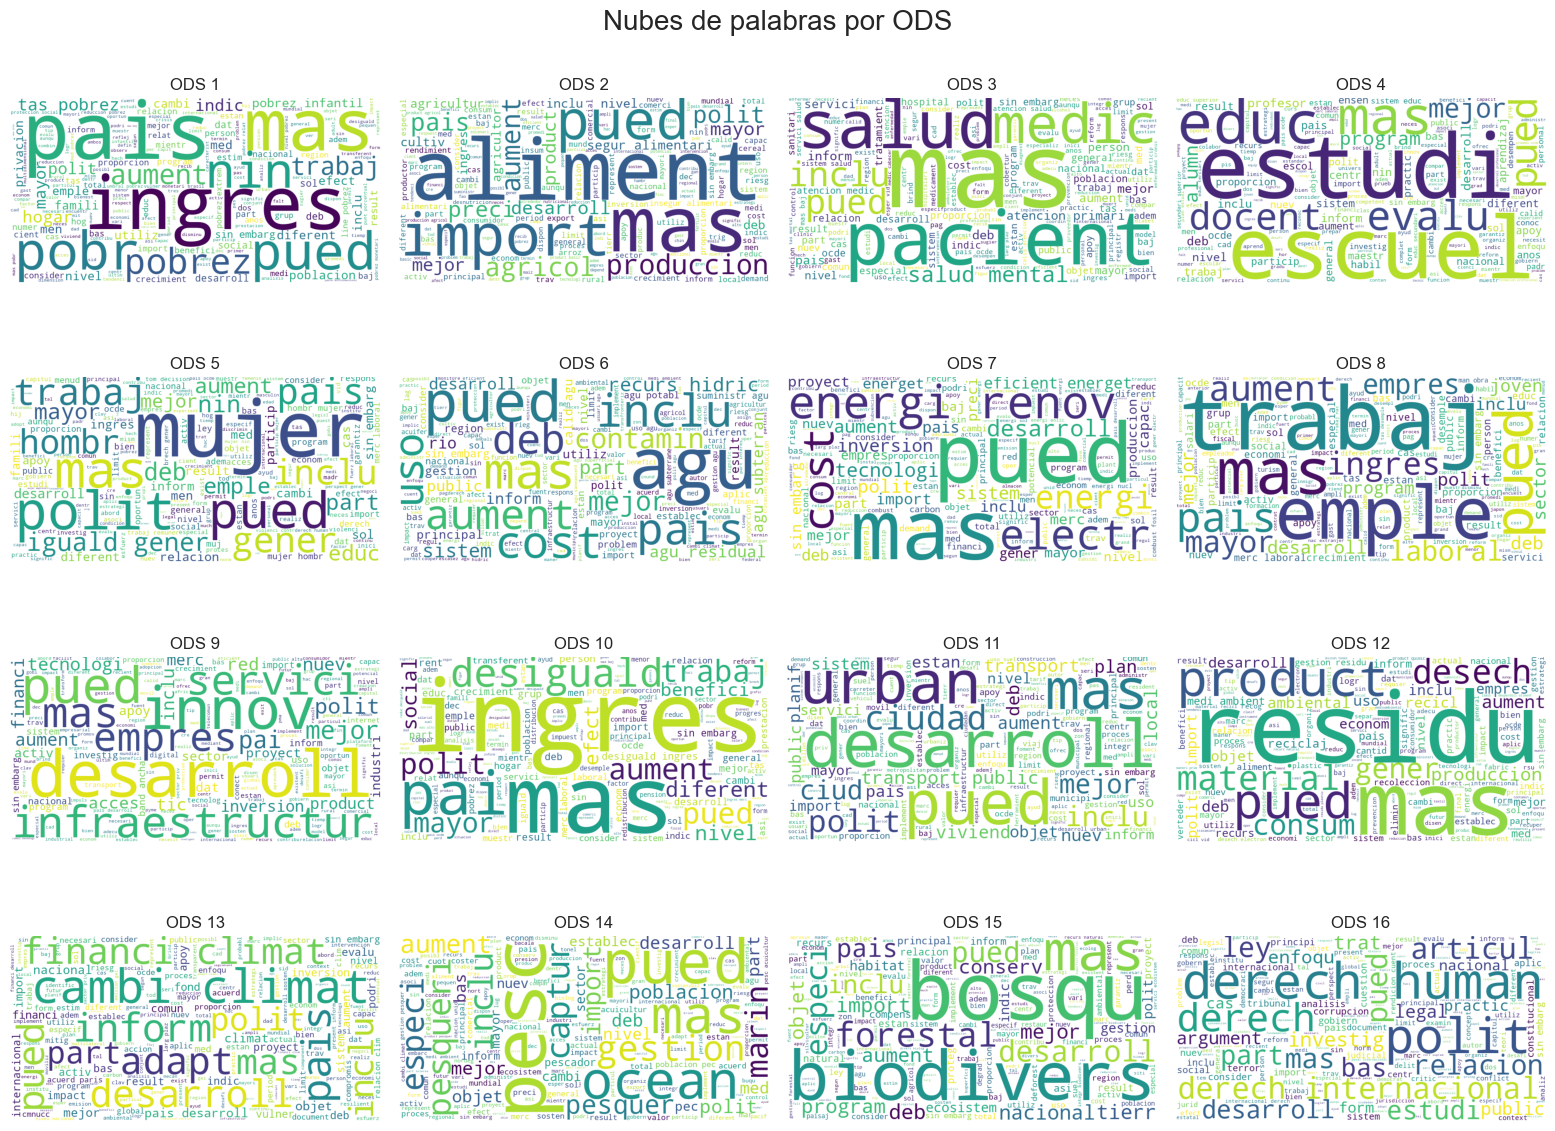

In [23]:
## hacerlo para analisis inicial
ods_list = sorted(df["ODS"].unique())

fig, axes = plt.subplots(4, 4, figsize=(16, 12))  # reducimos altura
axes = axes.flatten()

for i, ods in enumerate(ods_list):

    wc_text = " ".join(df[df["ODS"] == ods]["texto_limpio_stem"])

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(wc_text)

    axes[i].imshow(wordcloud)
    axes[i].set_title(f"ODS {ods}", fontsize=12)
    axes[i].axis('off')

# Título general más pegado arriba
fig.suptitle("Nubes de palabras por ODS", fontsize=20, y=0.98)

# Ajuste fino de espacios
plt.subplots_adjust(
    top=0.94,
    bottom=0.02,
    left=0.02,
    right=0.98,
    hspace=0.05,
    wspace=0.05
)

plt.show()


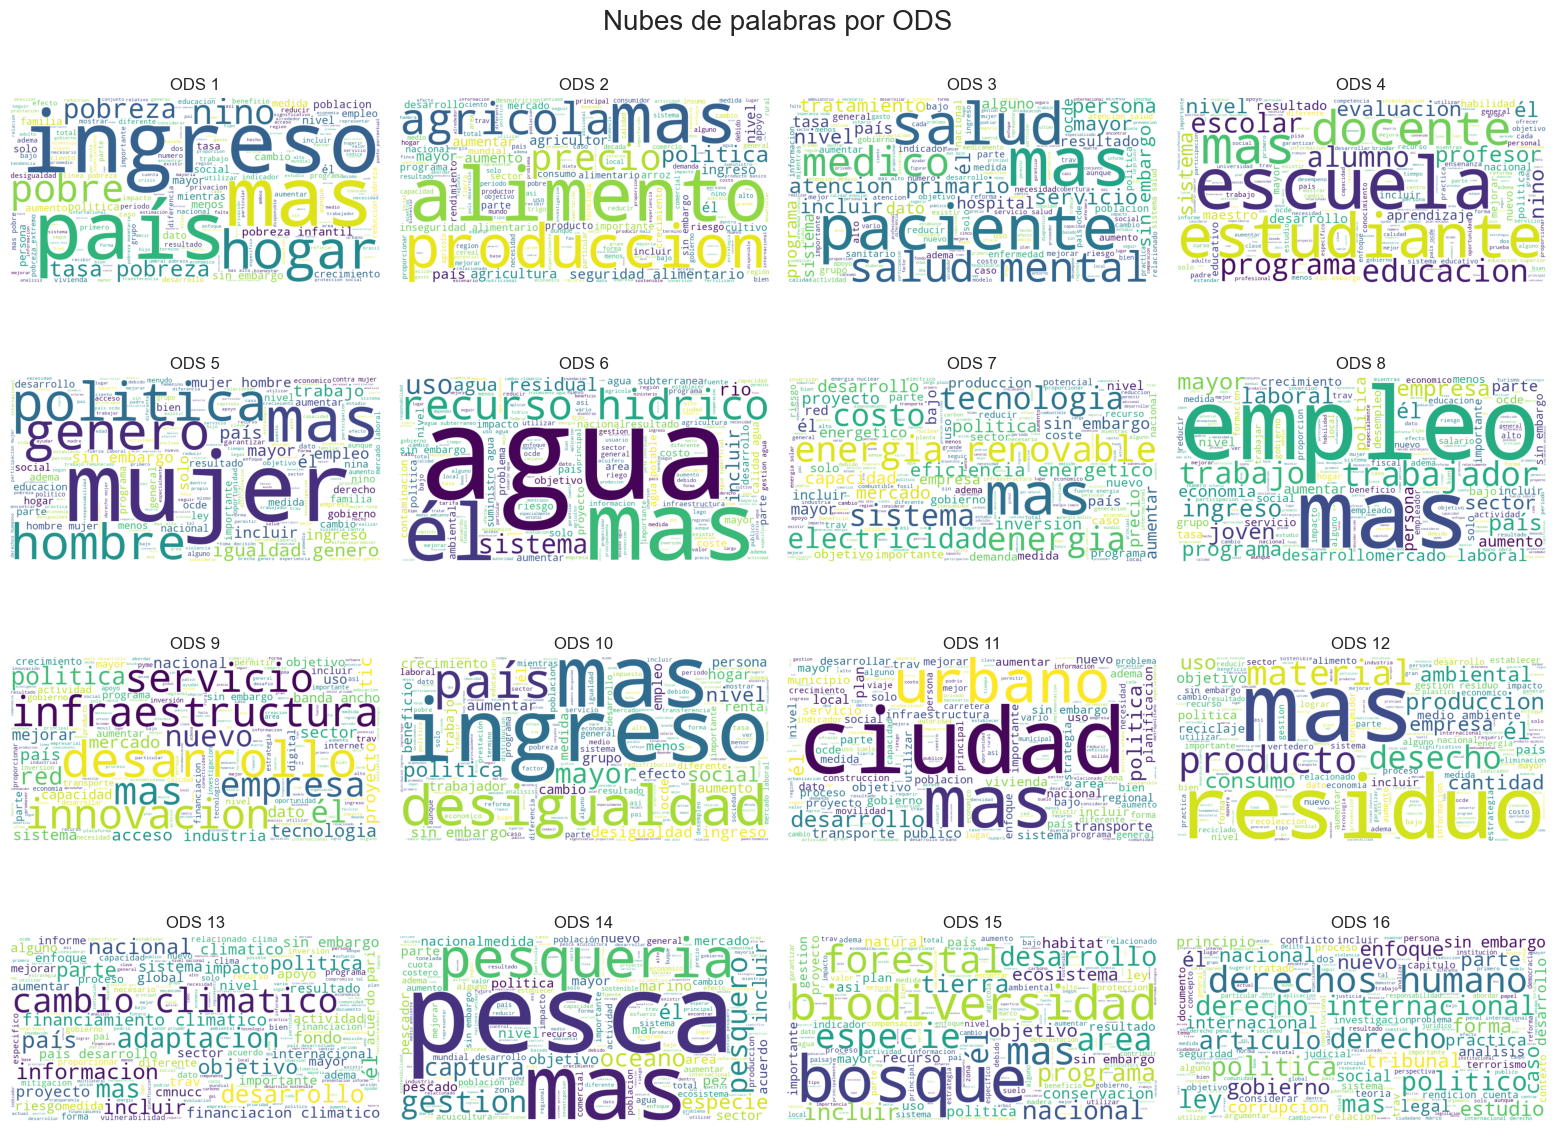

In [24]:
## hacerlo para analisis inicial
ods_list = sorted(df["ODS"].unique())

fig, axes = plt.subplots(4, 4, figsize=(16, 12))  # reducimos altura
axes = axes.flatten()

for i, ods in enumerate(ods_list):

    wc_text = " ".join(df[df["ODS"] == ods]["texto_limpio_spacy"])

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(wc_text)

    axes[i].imshow(wordcloud)
    axes[i].set_title(f"ODS {ods}", fontsize=12)
    axes[i].axis('off')

# Título general más pegado arriba
fig.suptitle("Nubes de palabras por ODS", fontsize=20, y=0.98)

# Ajuste fino de espacios
plt.subplots_adjust(
    top=0.94,
    bottom=0.02,
    left=0.02,
    right=0.98,
    hspace=0.05,
    wspace=0.05
)

plt.show()

## 4. Pruebas para elegir el modelo


In [25]:
### DIVIDIR EN TRAIN Y TEST
X = df["textos"]
y = df["ODS"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
display(X_train.shape)
display(X_test.shape)

(7724,)

(1932,)

In [27]:
y_train.value_counts(normalize=True)*100

ODS
16    11.185914
5     11.082341
4     10.616261
3      9.256862
7      8.143449
6      7.198343
11     6.279130
1      5.230451
13     4.803211
8      4.621958
14     3.909891
2      3.819265
10     3.650958
9      3.547385
15     3.417918
12     3.236665
Name: proportion, dtype: float64

In [28]:
y_test.value_counts(normalize=True)*100

ODS
16    11.180124
5     11.076605
4     10.610766
3      9.265010
7      8.178054
6      7.194617
11     6.314700
1      5.227743
13     4.813665
8      4.606625
14     3.881988
2      3.830228
10     3.623188
9      3.571429
15     3.416149
12     3.209110
Name: proportion, dtype: float64

In [29]:
## pipeline de procesamiento y reduccion de dimensionalidad 
pipe_features_lemma = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=limpiar_texto,
        ngram_range=(1,2),
        min_df=3,
        max_df=0.9,
        sublinear_tf=True
    )),
    ("svd", TruncatedSVD(n_components=100, random_state=42))
])


pipe_features_stem = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=limpiar_texto_stem,
        ngram_range=(1,2),
        min_df=3,
        max_df=0.9,
        sublinear_tf=True
    )),
    ("svd", TruncatedSVD(n_components=100, random_state=42))
])

In [30]:
X_train_trans_stem = pipe_features_stem.fit_transform(X_train)
X_test_trans_stem = pipe_features_stem.transform(X_test)


X_train_trans_lema = pipe_features_lemma.fit_transform(X_train)
X_test_trans_lema = pipe_features_lemma.transform(X_test)

In [31]:
## ver como funciona el pipeline
texto = X_train.iloc[0]
pipe_features_stem.fit(X_train)
tfidf_step = pipe_features_stem.named_steps["tfidf"]
svd_step = pipe_features_stem.named_steps["svd"]

print("TEXTO ORIGINAL:\n")
print(texto)

print("TEXTO LIMPIO:\n")
print(limpiar_texto_stem(texto))

tfidf_vec = tfidf_step.transform([texto])
print("\nTF-IDF shape:", tfidf_vec.shape)


feature_names = tfidf_step.get_feature_names_out()
indices = tfidf_vec.nonzero()[1]
scores = tfidf_vec.data

top_idx = scores.argsort()[::-1][:10]

print("\nTOP PALABRAS TF-IDF:")
for i in top_idx:
    print(feature_names[indices[i]], round(scores[i], 4))


svd_vec = pipe_features_stem.transform([texto])
print("\nSVD shape:", svd_vec.shape)
print("Primeros 5 componentes:", svd_vec[0][:5])

TEXTO ORIGINAL:

Por lo tanto, cabe esperar que el aumento de los niveles de ingresos posterior a la reforma de la asistencia social, tanto para los que tienen trabajo como para los que no tienen, tenga un efecto positivo en los niños. Una revisión de la evidencia sobre la reforma del bienestar y los resultados de los niños en los Estados Unidos (Waldfogel, 2007) concluye que los más vulnerables a tener un desempeño deficiente como resultado de los cambios de política son los muy jóvenes (menores de dos años) y los adolescentes. Es más probable que ocurran efectos perjudiciales cuando no hay ganancias en los ingresos, cuando las madres trabajan en empleos de salarios bajos o de muchas horas, o en trabajos que reducen la cantidad de tiempo de los padres con los niños (como trabajos con trabajo no estándar). horas de trabajo o viajes largos). La evidencia ha apoyado en gran medida la inversión en los servicios de los primeros años con Cunha y Heckman (2005) argumentando que la intervenci

In [32]:
## ver como funciona el pipeline LEMA
texto = X_train.iloc[0]
pipe_features_lemma.fit(X_train)
tfidf_step = pipe_features_lemma.named_steps["tfidf"]
svd_step = pipe_features_lemma.named_steps["svd"]

print("TEXTO ORIGINAL:\n")
print(texto)

print("TEXTO LIMPIO:\n")
print(limpiar_texto(texto))

tfidf_vec = tfidf_step.transform([texto])
print("\nTF-IDF shape:", tfidf_vec.shape)


feature_names = tfidf_step.get_feature_names_out()
indices = tfidf_vec.nonzero()[1]
scores = tfidf_vec.data

top_idx = scores.argsort()[::-1][:10]

print("\nTOP PALABRAS TF-IDF:")
for i in top_idx:
    print(feature_names[indices[i]], round(scores[i], 4))


svd_vec = pipe_features_lemma.transform([texto])
print("\nSVD shape:", svd_vec.shape)
print("Primeros 5 componentes:", svd_vec[0][:5])

TEXTO ORIGINAL:

Por lo tanto, cabe esperar que el aumento de los niveles de ingresos posterior a la reforma de la asistencia social, tanto para los que tienen trabajo como para los que no tienen, tenga un efecto positivo en los niños. Una revisión de la evidencia sobre la reforma del bienestar y los resultados de los niños en los Estados Unidos (Waldfogel, 2007) concluye que los más vulnerables a tener un desempeño deficiente como resultado de los cambios de política son los muy jóvenes (menores de dos años) y los adolescentes. Es más probable que ocurran efectos perjudiciales cuando no hay ganancias en los ingresos, cuando las madres trabajan en empleos de salarios bajos o de muchas horas, o en trabajos que reducen la cantidad de tiempo de los padres con los niños (como trabajos con trabajo no estándar). horas de trabajo o viajes largos). La evidencia ha apoyado en gran medida la inversión en los servicios de los primeros años con Cunha y Heckman (2005) argumentando que la intervenci

- y si hacemos una prueba rapida con un AutoML, para ver que modelos se comportan mejor.

In [33]:
# Train
X_train_df = pd.DataFrame(X_train_trans_lema)
X_train_df["ODS"] = y_train.values

# Test
X_test_df = pd.DataFrame(X_test_trans_lema)
X_test_df["ODS"] = y_test.values

In [34]:
exp = setup(
    data=X_train_df,
    target="ODS",
    session_id=42,
    fold=5,
    verbose=False
)

In [35]:
best = compare_models(sort="F1") 

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.8596,0.0000,0.8596,0.8578,0.8559,0.8478,0.8481,0.4640
lda,Linear Discriminant Analysis,0.8498,0.0000,0.8498,0.8687,0.8553,0.8378,0.8384,0.0300
svm,SVM - Linear Kernel,0.8526,0.0000,0.8526,0.8553,0.8478,0.8401,0.8409,0.4840
lightgbm,Light Gradient Boosting Machine,0.8407,0.9828,0.8407,0.8403,0.8390,0.8275,0.8277,12.6000
lr,Logistic Regression,0.8380,0.0000,0.8380,0.8395,0.8317,0.8240,0.8248,1.4420
xgboost,Extreme Gradient Boosting,0.8331,0.9840,0.8331,0.8325,0.8316,0.8194,0.8195,2.6580
rf,Random Forest Classifier,0.8339,0.9823,0.8339,0.8329,0.8307,0.8200,0.8203,0.7400
nb,Naive Bayes,0.8276,0.9796,0.8276,0.8379,0.8300,0.8136,0.8140,0.4740
et,Extra Trees Classifier,0.8306,0.9821,0.8306,0.8297,0.8260,0.8162,0.8166,0.2160
gbc,Gradient Boosting Classifier,0.8152,0.0000,0.8152,0.8184,0.8149,0.7999,0.8001,53.8220


In [36]:
best

RidgeClassifier(alpha=1.0, class_weight=None, copy_X=True, fit_intercept=True,
                max_iter=None, positive=False, random_state=42, solver='auto',
                tol=0.0001)

- Probamos los 3 mejores para tunear

In [37]:
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.svm import LinearSVC

In [38]:
modelos = {
    "Ridge_stem":     (RidgeClassifier(class_weight="balanced"),        X_train_trans_stem,  X_test_trans_stem),
    "Ridge_lemma":    (RidgeClassifier(class_weight="balanced"),        X_train_trans_lema,  X_test_trans_lema),
    "LinearSVC_stem": (LinearSVC(class_weight="balanced", random_state=42), X_train_trans_stem,  X_test_trans_stem),
    "LinearSVC_lemma":(LinearSVC(class_weight="balanced", random_state=42), X_train_trans_lema,  X_test_trans_lema),
    "LogReg_stem":    (LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42), X_train_trans_stem, X_test_trans_stem),
    "LogReg_lemma":   (LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42), X_train_trans_lema, X_test_trans_lema),
}

filas = []
modelos_entrenados = {}

for nombre, (clf, Xtr, Xte) in modelos.items():
    clf.fit(Xtr, y_train)
    modelos_entrenados[nombre] = clf

    # Train
    y_pred_tr = clf.predict(Xtr)
    # Test
    y_pred_te = clf.predict(Xte)

    filas.append({
        "modelo": nombre,
        "accuracy_train": accuracy_score(y_train, y_pred_tr),
        "balanced_accuracy_train": balanced_accuracy_score(y_train, y_pred_tr),
        "f1_macro_train": f1_score(y_train, y_pred_tr, average="macro"),
        "accuracy_test": accuracy_score(y_test, y_pred_te),
        "balanced_accuracy_test": balanced_accuracy_score(y_test, y_pred_te),
        "f1_macro_test": f1_score(y_test, y_pred_te, average="macro"),
    })

resultados = pd.DataFrame(filas).sort_values("f1_macro_test", ascending=False).reset_index(drop=True)
resultados

,modelo,accuracy_train,balanced_accuracy_train,f1_macro_train,accuracy_test,balanced_accuracy_test,f1_macro_test
0,LinearSVC_stem,0.885422,0.865480,0.862777,0.872671,0.845159,0.843378
1,LinearSVC_lemma,0.884645,0.863457,0.861348,0.871636,0.842448,0.839646
2,Ridge_lemma,0.866132,0.843507,0.840755,0.863872,0.835081,0.831989
3,LogReg_lemma,0.866779,0.849069,0.843387,0.863354,0.836609,0.831892
4,Ridge_stem,0.866132,0.845820,0.842476,0.859213,0.831111,0.829028
5,LogReg_stem,0.862377,0.846479,0.840033,0.856108,0.830146,0.825983


In [39]:
# ======================================================================
# LinearSVC_stem
# ======================================================================
print("="*80)
print("MODELO: LinearSVC_stem")
print("="*80)

clf_stem = modelos_entrenados["LinearSVC_stem"]
X_test_used = X_test_trans_stem

y_pred_stem = clf_stem.predict(X_test_used)

print("Accuracy:", round(accuracy_score(y_test, y_pred_stem), 4))
print("Balanced accuracy:", round(balanced_accuracy_score(y_test, y_pred_stem), 4))
print("F1 macro:", round(f1_score(y_test, y_pred_stem, average="macro"), 4))

print("\nReporte por ODS:\n")
print(classification_report(y_test, y_pred_stem))


# ======================================================================
# LinearSVC_lemma
# ======================================================================
print("="*80)
print("MODELO: LinearSVC_lemma")
print("="*80)

clf_lemma = modelos_entrenados["LinearSVC_lemma"]
X_test_used = X_test_trans_lema

y_pred_lemma = clf_lemma.predict(X_test_used)

print("Accuracy:", round(accuracy_score(y_test, y_pred_lemma), 4))
print("Balanced accuracy:", round(balanced_accuracy_score(y_test, y_pred_lemma), 4))
print("F1 macro:", round(f1_score(y_test, y_pred_lemma, average="macro"), 4))

print("\nReporte por ODS:\n")
print(classification_report(y_test, y_pred_lemma))

MODELO: LinearSVC_stem
Accuracy: 0.8727
Balanced accuracy: 0.8452
F1 macro: 0.8434

Reporte por ODS:

              precision    recall  f1-score   support

           1       0.87      0.79      0.83       101
           2       0.75      0.84      0.79        74
           3       0.93      0.92      0.93       179
           4       0.94      0.96      0.95       205
           5       0.92      0.92      0.92       214
           6       0.92      0.92      0.92       139
           7       0.93      0.90      0.91       158
           8       0.64      0.58      0.61        89
           9       0.67      0.77      0.72        69
          10       0.71      0.64      0.68        70
          11       0.84      0.80      0.82       122
          12       0.82      0.85      0.83        62
          13       0.84      0.85      0.84        93
          14       0.90      0.93      0.92        75
          15       0.88      0.88      0.88        66
          16       0.94      0.96

### Tunear mejor modelo


In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import clone
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.svm import LinearSVC


In [78]:
# ── Keywords específicas para ODS 8, 9, 10 ───────────────────────────────────
KEYWORDS_ODS8  = ["trabajo", "empleo", "desempleo", "salario", "laboral",
                  "economico", "productividad", "crecimiento", "comercio"]
KEYWORDS_ODS9  = ["industria", "innovacion", "infraestructura", "tecnologia",
                  "investigacion", "industrial", "manufactura"]
KEYWORDS_ODS10 = ["desigualdad", "inequidad", "equidad", "redistribucion",
                  "migracion", "inclusion", "brecha", "discriminacion"]
ALL_KEYWORDS   = KEYWORDS_ODS8 + KEYWORDS_ODS9 + KEYWORDS_ODS10

def keyword_features(texts):
    """Matriz binaria: 1 si la raíz del keyword aparece en el texto."""
    result = []
    for text in texts:
        t = str(text).lower()
        row = [1 if re.search(r'\b' + kw, t) else 0 for kw in ALL_KEYWORDS]
        result.append(row)
    return np.array(result, dtype=np.float64)


# ── Helper: construye pipeline con FeatureUnion (TF-IDF+SVD + keywords) ───────
def make_full_pipeline(clf):
    return Pipeline([
        ("features", FeatureUnion([
            ("tfidf_svd", Pipeline([
                ("tfidf", TfidfVectorizer(
                    preprocessor=limpiar_texto_stem,
                    min_df=3, max_df=0.9, sublinear_tf=True
                )),
                ("svd", TruncatedSVD(random_state=42)),
            ])),
            ("keywords", FunctionTransformer(keyword_features, validate=False)),
        ])),
        ("clf", clf),
    ])


# ── Parámetros comunes de features ────────────────────────────────────────────
feature_params = {
    "features__tfidf_svd__tfidf__ngram_range": [(1, 2), (1, 3)],
    "features__tfidf_svd__svd__n_components":  [100, 200, 300],
}

cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_arr = y_train.to_numpy() if hasattr(y_train, "to_numpy") else y_train


# ── GridSearch 1: LinearSVC ───────────────────────────────────────────────────
lsvc_param_grid = {
    **feature_params,
    "clf__C":            [0.1, 1, 10],
    "clf__class_weight": ["balanced", {8: 6, 9: 2, 10: 5}],
    "clf__loss":         ["squared_hinge"],
    "clf__tol":          [1e-5],
}

grid_lsvc = GridSearchCV(
    make_full_pipeline(LinearSVC(dual=True, random_state=42)),
    lsvc_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    refit=True,
    verbose=1,
)
grid_lsvc.fit(X_train, y_arr)


# ── GridSearch 2: LogisticRegression ──────────────────────────────────────────
lr_param_grid = {
    **feature_params,
    "clf__C":            [0.1, 1, 10],
    "clf__class_weight": ["balanced", {8: 6, 9: 2, 10: 5}],
    "clf__solver":       ["lbfgs"],
    "clf__max_iter":     [3000],
}

grid_lr = GridSearchCV(
    make_full_pipeline(LogisticRegression(random_state=42)),
    lr_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    refit=True,
    verbose=1,
)
grid_lr.fit(X_train, y_arr)


Fitting 5 folds for each of 240 candidates, totalling 1200 fits


/Applications/miniconda3/envs/pycaret/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Applications/miniconda3/envs/pycaret/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Applications/miniconda3/envs/pycaret/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Applications/miniconda3/envs/pycaret/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Applications/miniconda3/envs/pycaret/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Applications/minico

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             error_score=nan,
             estimator=LinearSVC(C=1.0, class_weight=None, dual=True,
                                 fit_intercept=True, intercept_scaling=1,
                                 loss='squared_hinge', max_iter=1000,
                                 multi_class='ovr', penalty='l2',
                                 random_state=42, tol=0.0001, verbose=0),
             n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100.0],
                         'class_weight': ['balanced', {8: 3, 9: 3, 10: 3},
                                          {8: 0.5, 9: 1, 10: 2},
                                          {8: 4, 9: 2, 10: 4},
                                          {8: 5, 9: 2, 10: 5}],
                         'loss': ['hinge', 'squared_hinge'],
                         'tol': [1e-05, 0.0001, 0.001, 0.01]},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=False,
             scoring='f1_weighted', verbose=1)

In [80]:
from sklearn.metrics import precision_recall_fscore_support

# ── Resultados: LinearSVC ─────────────────────────────────────────────────────
print("=" * 80)
print("MEJOR LinearSVC — parámetros:", grid_lsvc.best_params_)
print(f"CV f1_macro: {grid_lsvc.best_score_:.4f}")
y_pred_lsvc = grid_lsvc.best_estimator_.predict(X_test)
print("\nEN TEST:")
print("Accuracy:          ", round(accuracy_score(y_test, y_pred_lsvc), 4))
print("Balanced accuracy: ", round(balanced_accuracy_score(y_test, y_pred_lsvc), 4))
print("F1 macro:          ", round(f1_score(y_test, y_pred_lsvc, average="macro"), 4))
print(classification_report(y_test, y_pred_lsvc))

# ── Resultados: LogReg ────────────────────────────────────────────────────────
print("=" * 80)
print("MEJOR LogReg — parámetros:", grid_lr.best_params_)
print(f"CV f1_macro: {grid_lr.best_score_:.4f}")
y_pred_lr = grid_lr.best_estimator_.predict(X_test)
print("\nEN TEST:")
print("Accuracy:          ", round(accuracy_score(y_test, y_pred_lr), 4))
print("Balanced accuracy: ", round(balanced_accuracy_score(y_test, y_pred_lr), 4))
print("F1 macro:          ", round(f1_score(y_test, y_pred_lr, average="macro"), 4))
print(classification_report(y_test, y_pred_lr))

# ── Tabla comparativa (foco en ODS 8, 9, 10) ─────────────────────────────────
def class_f1(y_true, y_pred, cls):
    _, _, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=[cls], zero_division=0)
    return round(f[0], 3)

# Baseline: mejor LinearSVC anterior (sin ngrams/SVD/keywords optimizados)
best_clf_baseline = modelos_entrenados["LinearSVC_stem"]
y_pred_baseline   = best_clf_baseline.predict(X_test_trans_stem)

modelos_comp = [
    ("LinearSVC baseline (stem, SVD-100, bigrams)",   y_pred_baseline),
    ("LinearSVC + ngrams + SVD + keywords (tuneado)", y_pred_lsvc),
    ("LogReg   + ngrams + SVD + keywords (tuneado)",  y_pred_lr),
]

rows = []
for nombre, yp in modelos_comp:
    rows.append({
        "Modelo":           nombre,
        "F1 macro global":  round(f1_score(y_test, yp, average="macro"), 4),
        "Accuracy":         round(accuracy_score(y_test, yp), 4),
        "F1 ODS 8":         class_f1(y_test, yp, 8),
        "F1 ODS 9":         class_f1(y_test, yp, 9),
        "F1 ODS 10":        class_f1(y_test, yp, 10),
    })

comparison_df = pd.DataFrame(rows)
display(comparison_df.to_string(index=False))


Mejores parámetros: {'C': 1, 'class_weight': 'balanced', 'loss': 'squared_hinge', 'tol': 1e-05}
Mejor score (composite): 0.8678902995876199

En test:
Accuracy: 0.8727
F1 macro: 0.8434
              precision    recall  f1-score   support

           1       0.87      0.79      0.83       101
           2       0.75      0.84      0.79        74
           3       0.93      0.92      0.93       179
           4       0.94      0.96      0.95       205
           5       0.92      0.92      0.92       214
           6       0.92      0.92      0.92       139
           7       0.93      0.90      0.91       158
           8       0.64      0.58      0.61        89
           9       0.67      0.77      0.72        69
          10       0.71      0.64      0.68        70
          11       0.84      0.80      0.82       122
          12       0.82      0.85      0.83        62
          13       0.84      0.85      0.84        93
          14       0.90      0.93      0.92        75
     

- el modelo en general es bueno, pero tiene unas ods debiles.. podriamos dejarlo asi, o intentar nutrir esas clases (depronto de la msima manera que ellos lo mencionan con gpt), no se que tan bueno es hacer un smote con esto (para mi no haria mayor cosa, porque ya tenemos el parametro de class_weigth), la otra es variar cosas del pipeline de procesamiento tal vez con el tfidf (intentar con trigramas o algo asi) o variar lo componentes del svd

## 6. Modelo final y cómo funciona


In [86]:
# ── Seleccionar el mejor modelo entre los dos GridSearch ─────────────────────
if grid_lsvc.best_score_ >= grid_lr.best_score_:
    best_grid       = grid_lsvc
    best_model_name = "LinearSVC"
else:
    best_grid       = grid_lr
    best_model_name = "LogReg"

print(f"Modelo seleccionado: {best_model_name}")
print(f"CV f1_macro:         {best_grid.best_score_:.4f}")
print("Parámetros:", best_grid.best_params_)

# best_estimator_ ya fue reentrenado con todo X_train (refit=True)
final_pipeline = best_grid.best_estimator_


Pipeline(memory=None,
         steps=[('tfidf',
                 TfidfVectorizer(analyzer='word', binary=False,
                                 decode_error='strict',
                                 dtype=<class 'numpy.float64'>,
                                 encoding='utf-8', input='content',
                                 lowercase=True, max_df=0.9, max_features=None,
                                 min_df=3, ngram_range=(1, 2), norm='l2',
                                 preprocessor=<function limpiar_texto_stem at 0x13eee05e0>,
                                 smooth_idf=True, stop_words=None,
                                 strip_accents=No...
                 TruncatedSVD(algorithm='randomized', n_components=200,
                              n_iter=5, n_oversamples=10,
                              power_iteration_normalizer='auto',
                              random_state=42, tol=0.0)),
                ('clf',
                 LinearSVC(C=1, class_weight='balanced', dual=True,
                           fit_intercept=True, intercept_scaling=1,
                           loss='squared_hinge', max_iter=1000,
                           multi_class='ovr', penalty='l2', random_state=42,
                           tol=1e-05, verbose=0))],
         verbose=False)

In [ ]:
y_pred_opt = final_pipeline.predict(X_test)
print("=" * 80)
print(f"MODELO FINAL: {best_model_name}")
print("=" * 80)
print("Accuracy:          ", round(accuracy_score(y_test, y_pred_opt), 4))
print("Balanced accuracy: ", round(balanced_accuracy_score(y_test, y_pred_opt), 4))
print("F1 macro:          ", round(f1_score(y_test, y_pred_opt, average="macro"), 4))
print("\nReporte por ODS:\n")
print(classification_report(y_test, y_pred_opt))

print("\n--- Detalle ODS débiles (8, 9, 10) ---")
p, r, f, s = precision_recall_fscore_support(y_test, y_pred_opt, labels=[8, 9, 10], zero_division=0)
for i, ods in enumerate([8, 9, 10]):
    print(f"  ODS {ods}: precision={p[i]:.3f}  recall={r[i]:.3f}  f1={f[i]:.3f}  support={s[i]}")


MODELO
Accuracy: 0.8804
Balanced accuracy: 0.8541
F1 macro: 0.851

Reporte por ODS:

              precision    recall  f1-score   support

           1       0.84      0.80      0.82       101
           2       0.79      0.88      0.83        74
           3       0.95      0.92      0.93       179
           4       0.93      0.96      0.94       205
           5       0.93      0.95      0.94       214
           6       0.93      0.93      0.93       139
           7       0.92      0.90      0.91       158
           8       0.62      0.56      0.59        89
           9       0.71      0.75      0.73        69
          10       0.68      0.63      0.65        70
          11       0.87      0.85      0.86       122
          12       0.83      0.89      0.86        62
          13       0.85      0.86      0.86        93
          14       0.89      0.95      0.92        75
          15       0.87      0.89      0.88        66
          16       0.97      0.95      0.96       

- calibro para obtener las probabilidades de que ese texto pertenezca a ese ods

In [87]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    final_pipeline,
    method="sigmoid",  # o "isotonic"
    cv=5               # CV solo en train
)

calibrated_model.fit(X_train, y_train)

CalibratedClassifierCV(cv=5, ensemble=True,
                       estimator=Pipeline(memory=None,
                                          steps=[('tfidf',
                                                  TfidfVectorizer(analyzer='word',
                                                                  binary=False,
                                                                  decode_error='strict',
                                                                  dtype=<class 'numpy.float64'>,
                                                                  encoding='utf-8',
                                                                  input='content',
                                                                  lowercase=True,
                                                                  max_df=0.9,
                                                                  max_features=None,
                                                                  min_df=3,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  norm='l2',
                                                                  preprocessor=<function limpiar_texto_stem at 0x13eee05...
                                                  TruncatedSVD(algorithm='randomized',
                                                               n_components=200,
                                                               n_iter=5,
                                                               n_oversamples=10,
                                                               power_iteration_normalizer='auto',
                                                               random_state=42,
                                                               tol=0.0)),
                                                 ('clf',
                                                  LinearSVC(C=1,
                                                            class_weight='balanced',
                                                            dual=True,
                                                            fit_intercept=True,
                                                            intercept_scaling=1,
                                                            loss='squared_hinge',
                                                            max_iter=1000,
                                                            multi_class='ovr',
                                                            penalty='l2',
                                                            random_state=42,
                                                            tol=1e-05,
                                                            verbose=0))],
                                          verbose=False),
                       method='sigmoid', n_jobs=None)

In [88]:
probs = calibrated_model.predict_proba(X_test)

In [89]:
idx = 0  

probs_1 = calibrated_model.predict_proba(X_test[idx:idx+1])[0]
clases = calibrated_model.classes_

pred_idx = np.argmax(probs_1)
print("Texto idx:", idx)
print("Pred:", clases[pred_idx], "proba:", probs_1[pred_idx])

Texto idx: 0
Pred: 5 proba: 0.704160349508585


In [90]:
X_test[idx:idx+1]

5100    En la última década, muchos de los procesos de paz en el continente africano entre 1991 y 2012 no tuvieron mujeres como mediadoras principales. Maximizar los beneficios de la participación de las mujeres en la prevención de conflictos y la consolidación de la paz exige pasar de la inclusión a la asociación para el cambio social. La ausencia de las mujeres en los procesos de paz no puede explicarse por su supuesta falta de experiencia en resolución de conflictos o negociaciones.
Name: textos, dtype: object

In [91]:
y_test[idx:idx+1]

5100    5
Name: ODS, dtype: int64

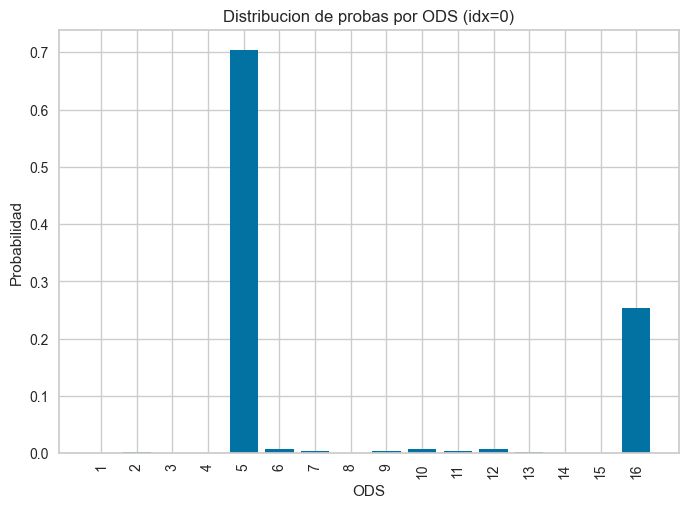

In [92]:
plt.figure()
plt.bar([str(c) for c in clases], probs_1)
plt.xlabel("ODS")
plt.ylabel("Probabilidad")
plt.title(f"Distribucion de probas por ODS (idx={idx})")
plt.xticks(rotation=90)
plt.show()

In [93]:
k = 5
topk = np.argsort(probs_1)[::-1][:k]
for i in topk:
    print(f"ODS {clases[i]}: {probs_1[i]:.4f}")

ODS 5: 0.7042
ODS 16: 0.2528
ODS 6: 0.0082
ODS 12: 0.0080
ODS 10: 0.0072


In [ ]:
import joblib

['modelo_ods_calibrado.joblib']

In [97]:
# Guardar el modelo calibrado final
joblib.dump(calibrated_model, "modelo_ods_calibrado.joblib")
print(f"Modelo guardado: modelo_ods_calibrado.joblib  ({best_model_name})")


['pipeline_calibrado.pkl']